# Finite-Difference Operators in 2-D

by Manuel A. Diaz on 06.05.2026

## Preamble

In [1]:
# Packages
from os import makedirs

import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

from fdx import finite_differences_grid as Ω

PATH = "../figures/div_curl"
makedirs(PATH, exist_ok=True)

In [2]:
# Auxiliary plotting function
def plot_div_curl(
    grid,
    vField,
    figsize=(16, 6),
    cmap="jet",
    vmin=-5,
    vmax=5,
    quiver_color="black",
    dpi=150,
    savepath=None,
):
    """
    Plot divergence and curl of a 2D vector field side by side.

    Parameters
    ----------
    grid      : Ω.Grid2d object with .Div() and .Curl() methods
    vField    : list [Fx, Fy] of 2D arrays representing the vector field
    figsize   : tuple, figure size (width, height)
    cmap      : colormap for pcolormesh
    vmin/vmax : color scale limits
    quiver_color : color of the quiver arrows
    dpi       : resolution for saved figure
    savepath  : str or None — if provided, saves the figure to this path

    Returns
    -------
    fig, axes : the matplotlib Figure and Axes array
    """
    X, Y = np.meshgrid(grid.x, grid.y)

    datasets = [
        (grid.Div(vField), "Divergence"),
        (grid.Curl(vField), "Curl"),
    ]

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    for ax, (data, label) in zip(axes, datasets):
        im = ax.pcolormesh(X, Y, data, shading="auto", cmap=cmap, vmin=vmin, vmax=vmax)
        ax.quiver(X, Y, vField[0], vField[1], color=quiver_color, pivot="mid")
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="3%", pad=0.05)
        fig.colorbar(im, cax=cax).set_label(label)
        ax.set_title(label)
        ax.axis("equal")

    plt.tight_layout()
    plt.show()

    if savepath is not None:
        fig.savefig(savepath, dpi=dpi, bbox_inches="tight")

    # return fig, axes

## Compute divergence and curl of vector fields

In [3]:
# Build a common 2-d grid for all examples
grid = Ω.Grid2d(xa=-5.0, xb=5.0, nx=24, ya=-3.0, yb=3.0, ny=14)
x, y = np.meshgrid(grid.x, grid.y)

### Introduction to divergence and curl

Let $\vec{F} = \langle p, q \rangle$ be a vector field in $\mathbb{R}^2$ (a 2-dimensional vector space) if $p$ and $q$ are real-valued functions defined on $\mathbb{R}^2$. Then, the divergence of $\vec{F}$ is given by:

$$
\nabla \cdot \vec{F} = \frac{\partial p}{\partial x} + \frac{\partial q}{\partial y}
$$

Note that the divergence is a scalar field, and it is the sum of the partial derivatives of the components of the vector field. Moreover, the result is a scalar field. 

In terms of the gradient operator 

$$
\nabla  = \langle\frac{\partial}{\partial x}, \frac{\partial}{\partial y}\rangle
$$,

the divergence operator can be written in terms of the gradient operator $\nabla$ as:

$$
div \vec{F} = \nabla \cdot \vec{F}
$$

Physically, the divergence of a vector field is a measure of the expansion or contraction of the field.

`Definition`: 
For the 2-dimensional vector field $\vec{F} = \langle p, q \rangle$, the divergence is given by:

$$
\nabla \cdot \vec{F} = \frac{\partial p}{\partial x} + \frac{\partial q}{\partial y}
$$

Similarly, in terms of the gradient operator, the curl of $\vec{F}$ can also be expressed in terms of the gradient operator $\nabla$ as:

$$
curl \vec{F} = \nabla \times \vec{F}
$$

`Definition`: 
For the 2-dimensional vector field $\vec{F} = \langle p, q \rangle$, the curl is given by:
$$
\nabla \times \vec{F} = \frac{\partial q}{\partial x} - \frac{\partial p}{\partial y}
$$

Physically, the curl of a vector field is a measure of the rotation of the field.

### Example 1: constant vector field

Let us consider the field $\vec{F} = \langle 1, 2 \rangle$.

Analitically the divergence and curl of this field are:

$$
\nabla \cdot \vec{F} = \frac{\partial}{\partial x}(1) + \frac{\partial}{\partial y}(2) = 0
$$

and 

$$
\nabla \times \vec{F} = \frac{\partial}{\partial x}(2) - \frac{\partial}{\partial y}(1) = 0
$$

respectively. 

Numerically, we can compute the divergence and curl of this field using the `Div()` and `Curl()` methods of the `Grid2d` class.

```python
div_F = grid.Div([np.ones_like(x), 2 * np.ones_like(x)])
curl_F = grid.Curl([np.ones_like(x), 2 * np.ones_like(x)])
```

Constant vector field


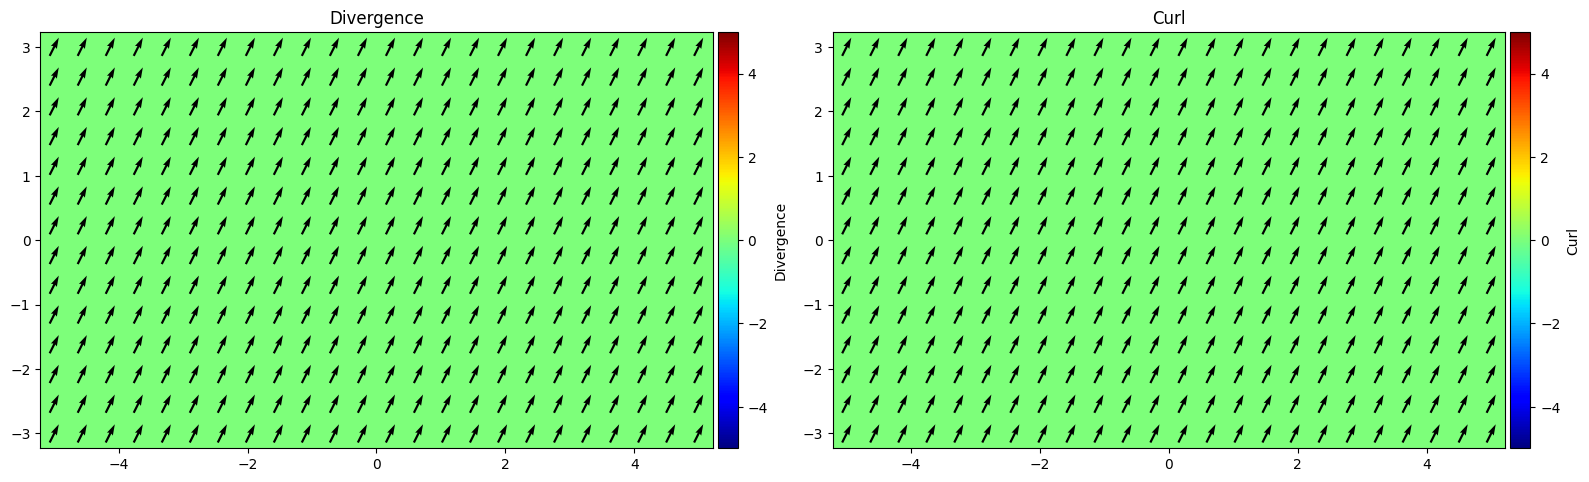

In [4]:
print("Constant vector field")
vField = [np.ones_like(x), 2 * np.ones_like(x)]
plot_div_curl(grid, vField)

As expected, the divergence and curl of the constant vector field are zero.

### Example 2: purely rotational vector field

Let us consider the field $\vec{F} = \langle -y, x \rangle$.

Analitically the divergence and curl of this field are:

$$
\nabla \cdot \vec{F} = \frac{\partial}{\partial x}(-y) + \frac{\partial}{\partial y}(x) = 0
$$

and 

$$
\nabla \times \vec{F} = \frac{\partial}{\partial x}(x) - \frac{\partial}{\partial y}(-y) = 2
$$

respectively.

Numerically, we again proceed as follows:

```python
div_F = grid.Div([-y, x])
curl_F = grid.Curl([-y, x])
```


Purely rotational vector field


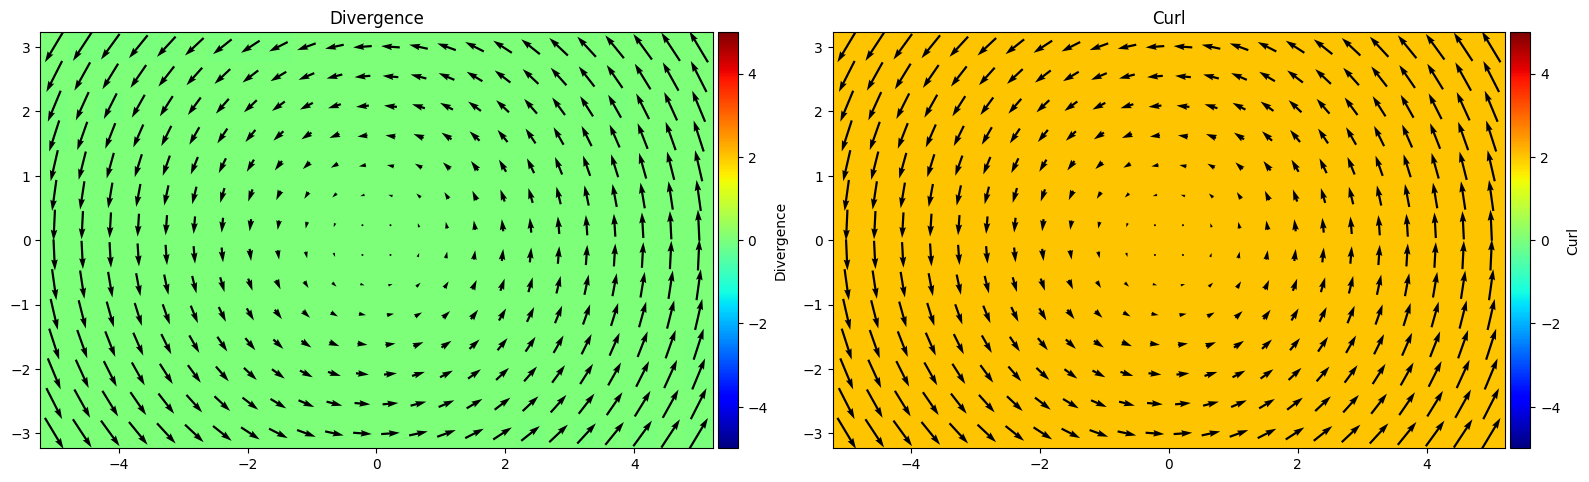

In [5]:
print("Purely rotational vector field")
vField = [-y, x]
plot_div_curl(grid, vField)

As expected, the divergence of the purely rotational vector field is zero, and the curl is constant and equal to 2.

### Example 3: purely expanding vector field

Let us consider the field $\vec{F} = \langle x, y \rangle$.

Analitically the divergence and curl of this field are:

$$
\nabla \cdot \vec{F} = \frac{\partial}{\partial x}(x) + \frac{\partial}{\partial y}(y) = 2
$$

and 

$$
\nabla \times \vec{F} = \frac{\partial}{\partial x}(y) - \frac{\partial}{\partial y}(x) = 0
$$

respectively.

Similarly, numerically we proceed as follows:

```python
div_F = grid.Div([x, y])
curl_F = grid.Curl([x, y])
```

Purely expanding vector field


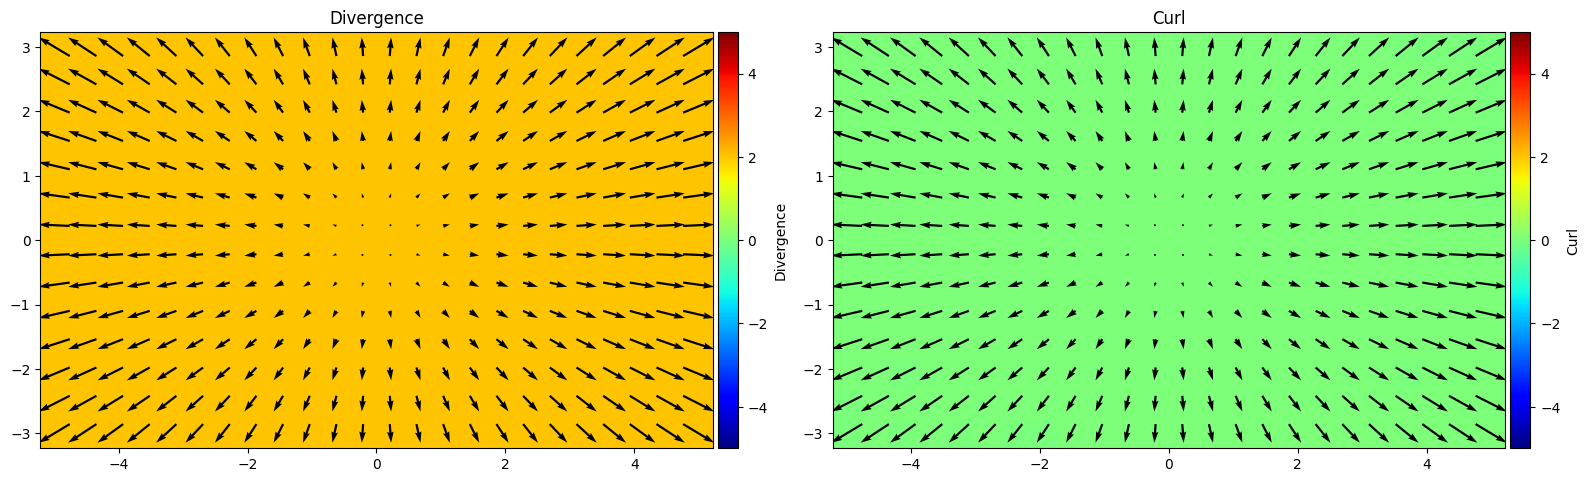

In [6]:
print("Purely expanding vector field")
vField = [x, y]
plot_div_curl(grid, vField)

As expected, the divergence of the purely expanding vector field is constant and equal to 2, and the curl is zero.

### Example 4: purely shrinking vector field

Let us consider the field $\vec{F} = \langle -x, -y \rangle$.

Analitically the divergence and curl of this field are:

$$
\nabla \cdot \vec{F} = \frac{\partial}{\partial x}(-x) + \frac{\partial}{\partial y}(-y) = -2
$$

and 

$$
\nabla \times \vec{F} = \frac{\partial}{\partial x}(-y) - \frac{\partial}{\partial y}(-x) = 0
$$

respectively.

Numerically, we proceed as follows:

```python
div_F = grid.Div([-x, -y])
curl_F = grid.Curl([-x, -y])
```

Purely shrinking vector field


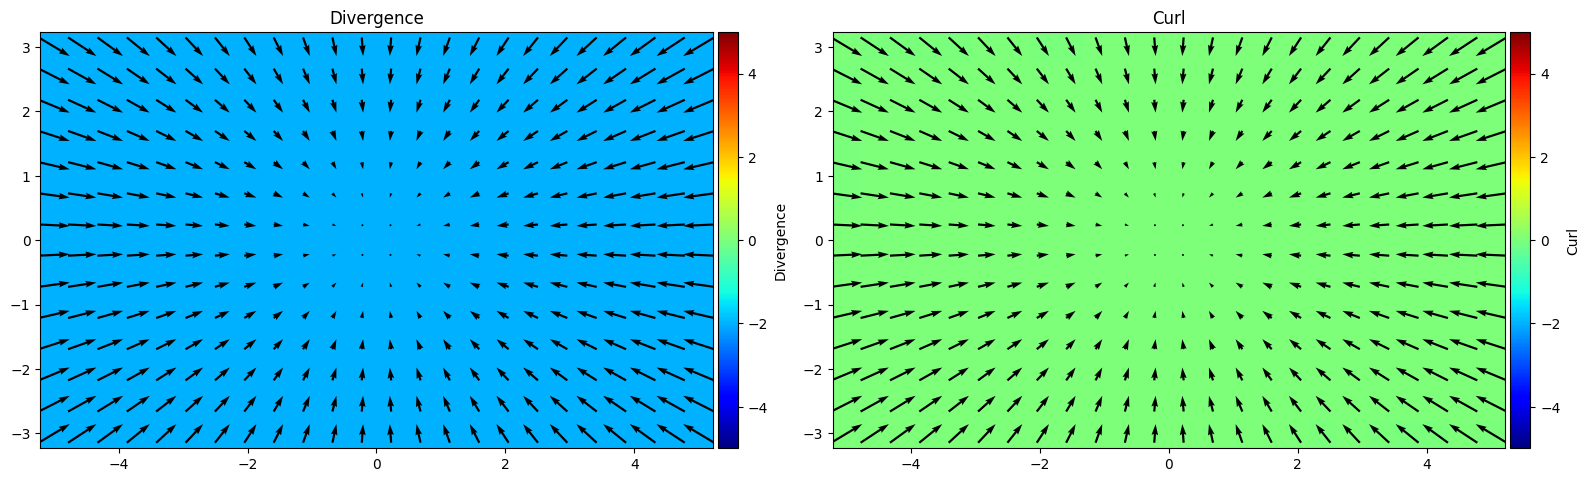

In [7]:
print("Purely shrinking vector field")
vField = [-x, -y]
plot_div_curl(grid, vField)

As expected, the divergence of the purely shrinking vector field is constant and equal to -2, and the curl is zero.

### Example 5: non-linear vector field

Let us consider the field $\vec{F} = \langle x^2 y, y - x y^2 \rangle$.

Analitically the divergence and curl of this field are:

$$
\nabla \cdot \vec{F} = \frac{\partial}{\partial x}(x^2 y) + \frac{\partial}{\partial y}(y - x y^2) = 2xy + 1 - 2xy = 1
$$

and 

$$
\nabla \times \vec{F} = \frac{\partial}{\partial x}(y - x y^2) - \frac{\partial}{\partial y}(x^2 y) = -2xy - 2xy = -4xy
$$

respectively.

Numerically, we proceed as follows:
```python
div_F = grid.Div([x**2 * y, y - x * y**2])
curl_F = grid.Curl([x**2 * y, y - x * y**2])
```

Non-linear vector field


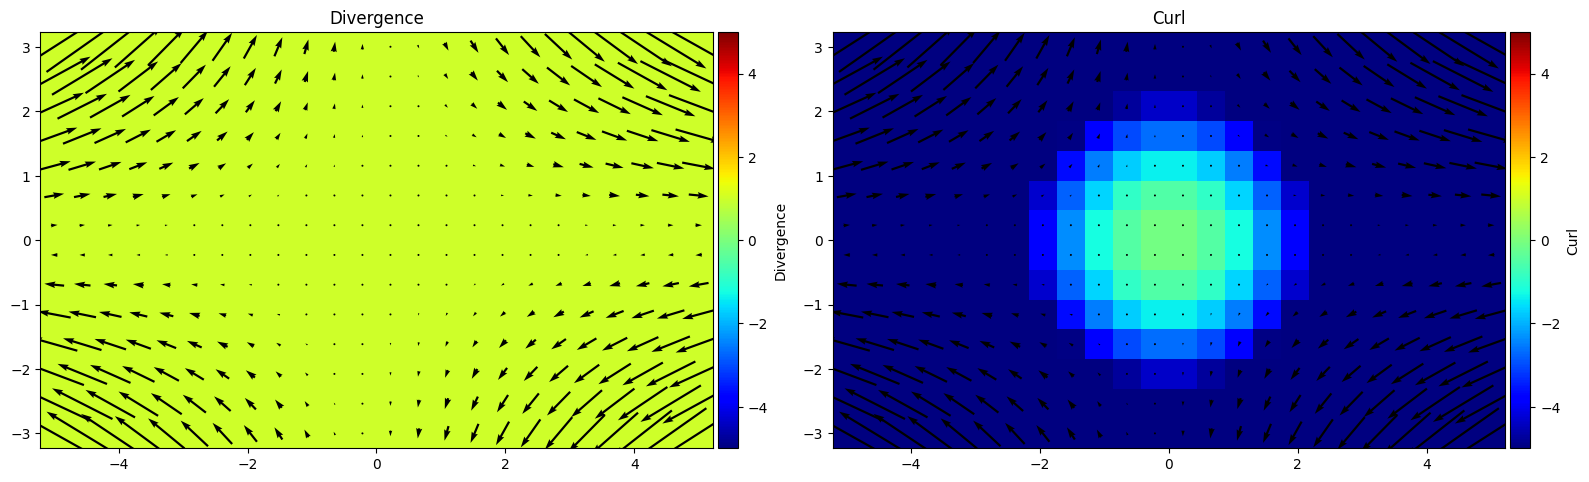

In [8]:
print("Non-linear vector field")
vField = [x**2 * y, y - x * y**2]
plot_div_curl(grid, vField)

As expected, the divergence of the non-linear vector field is constant and equal to 1, and the curl is non-zero. This type of field behaviour starts to resemble a fluid flow.

### Example 6: fluid flow vector field

Let us consider the field $\vec{F} = \langle -x y, y \rangle$.

Analitically the divergence and curl of this field are:

$$
\nabla \cdot \vec{F} = \frac{\partial}{\partial x}(-x y) + \frac{\partial}{\partial y}(y) = -y
$$

and

$$
\nabla \times \vec{F} = \frac{\partial}{\partial x}(y) - \frac{\partial}{\partial y}(-x y) = 1 + x
$$

respectively.

Numerically, we proceed as follows:

```python
div_F = grid.Div([-x * y, y])
curl_F = grid.Curl([-x * y, y])
```

Fluid flow vector field


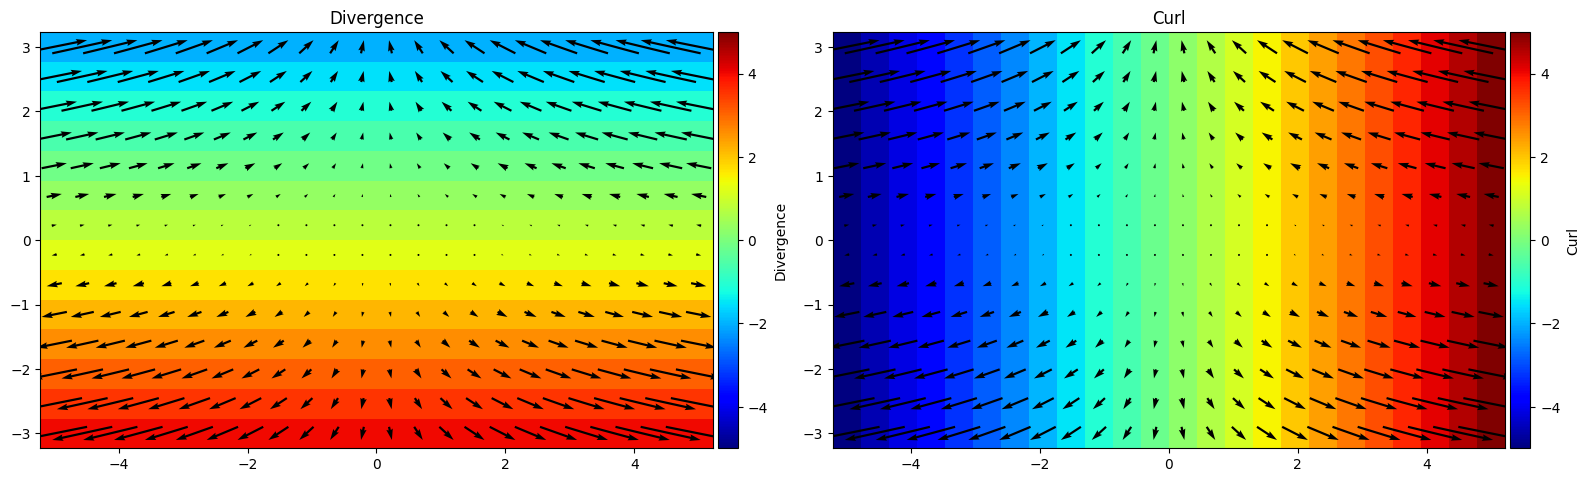

In [9]:
print("Fluid flow vector field")
vField = [-x * y, y]
plot_div_curl(grid, vField)

As expected, the divergence of the fluid flow vector field is non-zero, and the curl is constant and equal to 1. Again, this field resembles a fluid flow and the pattern of colors is a good visual representation of the field.

### Example 7: shear flow vector field

Let us consider the field $\vec{F} = \langle y, 0 \rangle$.

Analitically the divergence and curl of this field are:

$$
\nabla \cdot \vec{F} = \frac{\partial}{\partial x}(y) + \frac{\partial}{\partial y}(0) = 0
$$

and

$$
\nabla \times \vec{F} = \frac{\partial}{\partial x}(0) - \frac{\partial}{\partial y}(y) = -1
$$

respectively.

Numerically, we proceed as follows:

```python
div_F = grid.Div([y, np.zeros_like(x)])
curl_F = grid.Curl([y, np.zeros_like(x)])
```

Shear flow vector field


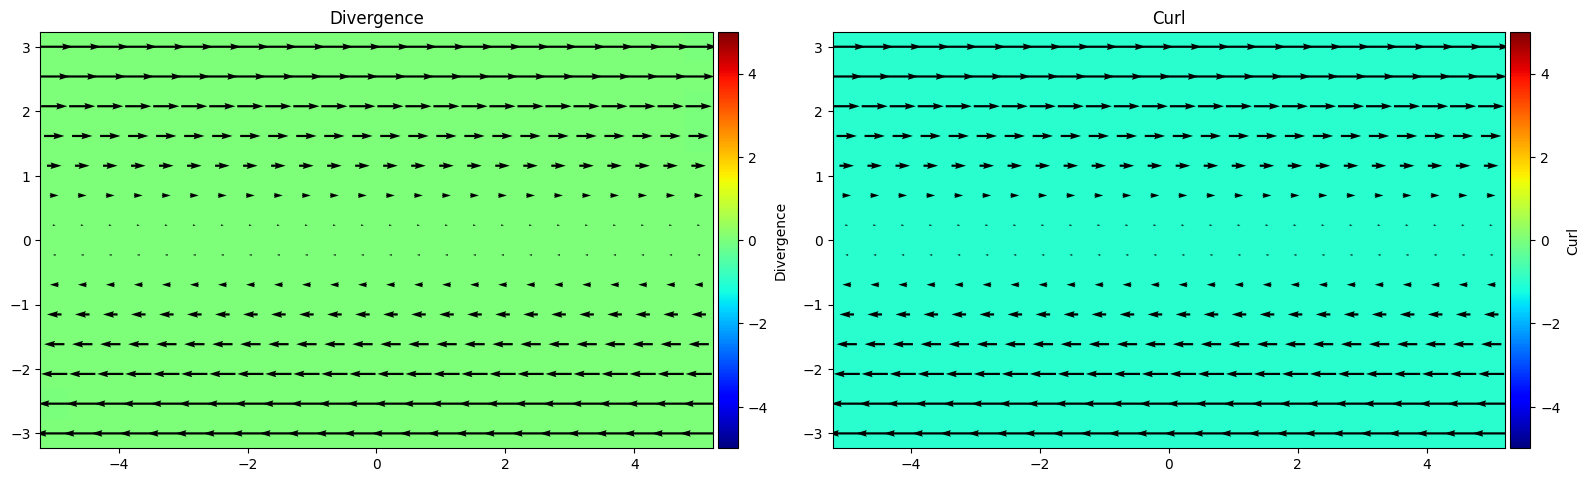

In [10]:
print("Shear flow vector field")
vField = [y, np.zeros_like(x)]
plot_div_curl(grid, vField)

In material mechanics can result from shear stresses. In fluid mechanics can also results in a shear flow. An by shear, lets think about a cutting motion. As expected, the divergence of the shear flow vector field is zero, and the curl is non-zero.

### Example 8: gravitational vector field (sink point source)

Newton's law of universal gravitation can be written as a vector equation to account for the direction of the gravitational force as well as its magnitude. In this formula, quantities in bold represent vectors.

$$
\vec{F}_{12} = -\frac{G m_1 m_2}{|\vec{r}_{12}|^2} \hat{r}_{12}
$$

where $G$ is the gravitational constant, $m_1$ and $m_2$ are the masses of the two objects, and $\hat{r}_{12}$ is the unit vector pointing from object 1 to object 2 and $|\vec{r}_{12}|$ is the distance between the two objects. In this model, $G$, $m_1$ and $m_2$ are constants that scale the magnitude of the force. The field is defined by $\frac{\hat{r}_{12}}{|\vec{r}_{12}|^2}$ term, which in 2-d we here approximate as

$$
\vec{F}_{12} \approx \langle \frac{-x}{\sqrt{x^2 + y^2}}, \frac{-y}{ \sqrt{x^2 + y^2}} \rangle
$$.

Numerically, we proceed as follows:

```python
div_F = grid.Div([-x / np.hypot(x, y), -y / np.hypot(x, y)])
curl_F = grid.Curl([-x / np.hypot(x, y), -y / np.hypot(x, y)])
```
Notice that in numpy, the power and division operations are produced element-wise.

Gravitational vector field (sink point source)


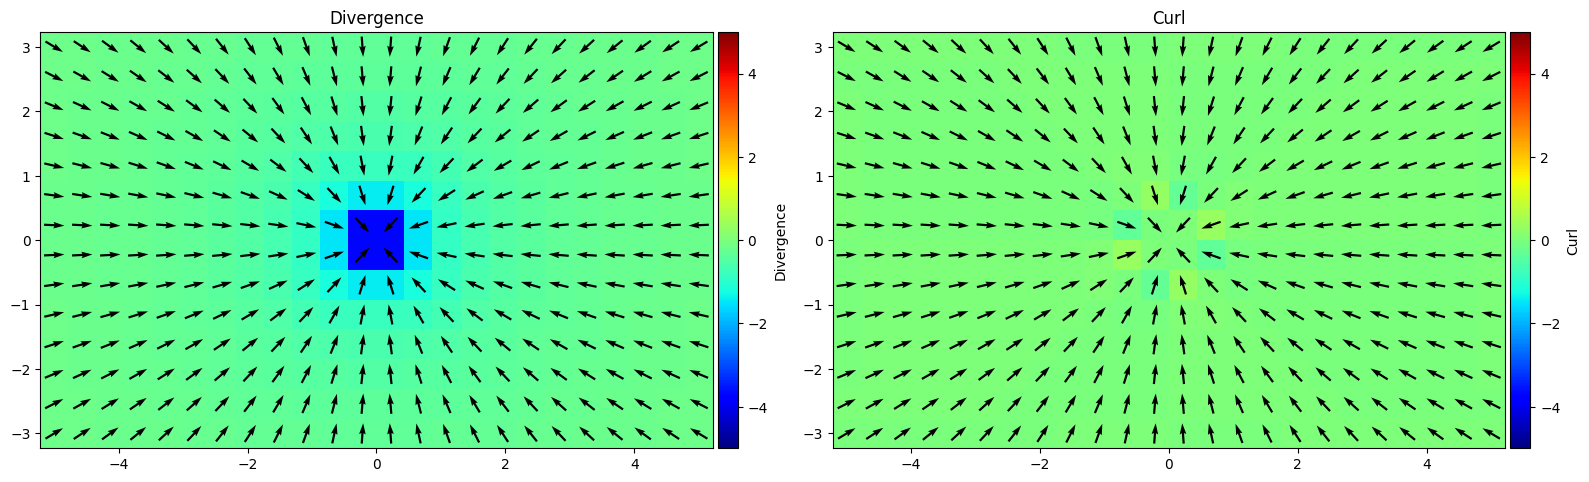

In [11]:
print("Gravitational vector field (sink point source)")
vField = [-x / np.hypot(x, y), -y / np.hypot(x, y)]
plot_div_curl(grid, vField)

As expected, the divergence of the gravitational vector field is non-zero, but the curl is zero.

In Electrostatics this field resembles a sink point charge. The color pattern that we observe near the origin is only a ``fair'' representation because of how numerically a singularity is handled with smooth functions used on our finite-difference grid.

Nevertheless, far from the singularity, the solution is a good approximation of the analytical solution.

### Example 9: Trigonometric vector field

Let us consider the field 

$$
\vec{F} = \langle \cos(x + 2 y), \sin(x - 2 y) \rangle
$$.

In this case, the divergence and curl are not expected to be zero.

Numerically, we proceed as follows:

```python
div_F = grid.Div([np.cos(x + 2 * y), np.sin(x - 2 * y)])
curl_F = grid.Curl([np.cos(x + 2 * y), np.sin(x - 2 * y)])
```

Trigonometric vector field


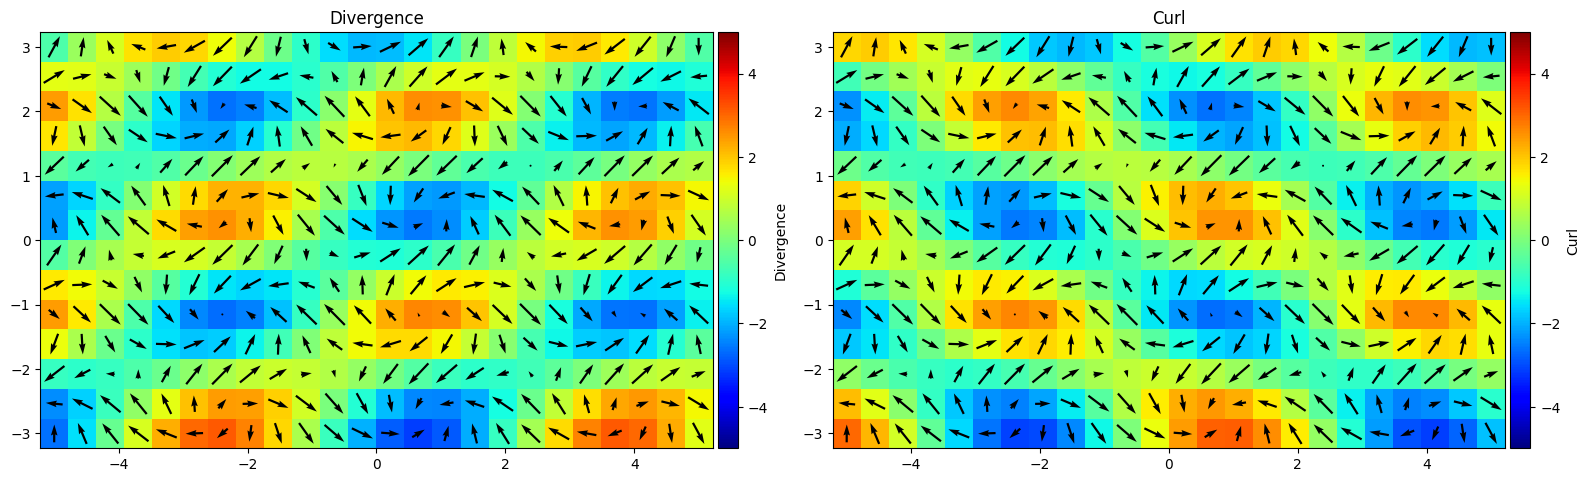

In [12]:
print("Trigonometric vector field")
vField = [np.cos(x + 2 * y), np.sin(x - 2 * y)]
plot_div_curl(grid, vField)

As expected, the divergence and curl of the trigonometric vector field are not zero.

### Example 10: Magnetic vector field (sink and source points of equal magnitude)

Let us consider the field 

$$
\vec{V}(\vec{r}) = \left(\frac{1}{|\vec{r}-\vec{r}_1|} - \frac{1}{|\vec{r}-\vec{r}_{2}|}\right)
$$.

Numerically, we proceed as follows:

Magnetic vector field (sink and source points)


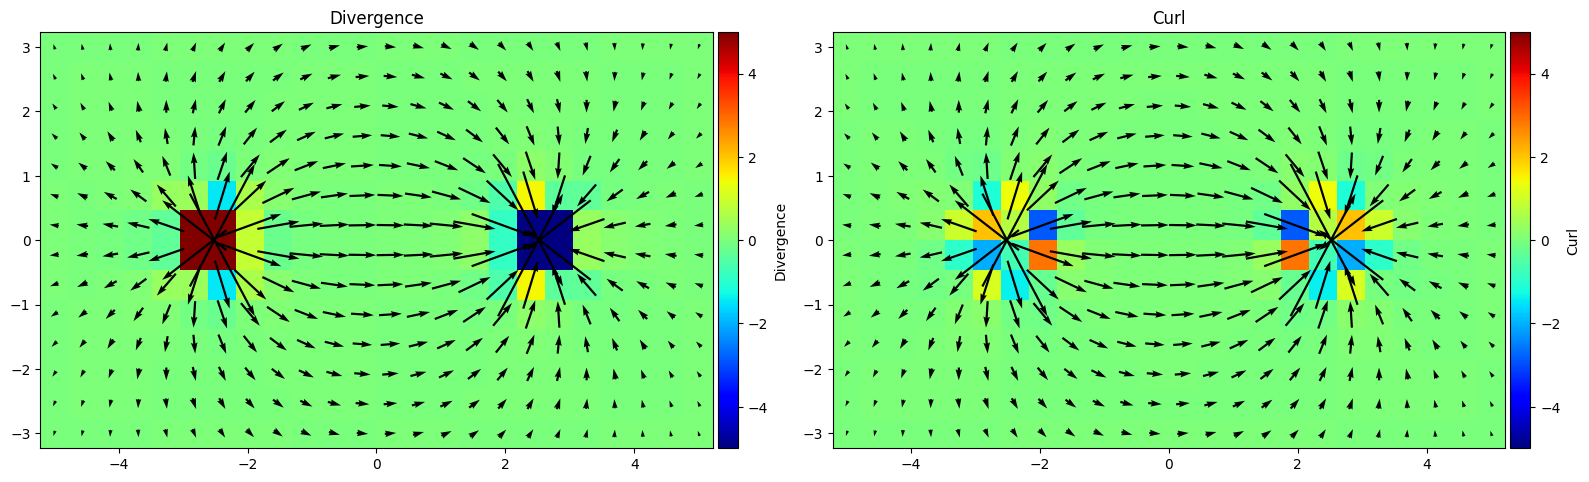

In [13]:
print("Magnetic vector field (sink and source points)")

# Charges locations
src = np.array([-2.5, 0.0])
snk = np.array([2.5, 0.0])

# Displacements vector from each charge
dx1, dy1 = x - src[0], y - src[1]
dx2, dy2 = x - snk[0], y - snk[1]

r1 = np.hypot(dx1, dy1)
r2 = np.hypot(dx2, dy2)

# Unit vectors
ex1, ey1 = dx1 / r1, dy1 / r1
ex2, ey2 = dx2 / r2, dy2 / r2

# Normalize unit vectors
e1_mag = np.hypot(ex1, ey1)
e2_mag = np.hypot(ex2, ey2)
ex1, ey1 = ex1 / e1_mag, ey1 / e1_mag
ex2, ey2 = ex2 / e2_mag, ey2 / e2_mag

# Mask near the charges to avoid singularity
eps = 0.1
r1_safe = np.where(r1 < eps, np.nan, r1)
r2_safe = np.where(r2 < eps, np.nan, r2)

# Field components (source - sink)
Vx = ex1 / r1_safe - ex2 / r2_safe
Vy = ey1 / r1_safe - ey2 / r2_safe

# Plot the field
vField = [Vx, Vy]
plot_div_curl(grid, vField)

The electrostatic field of a point charge (sink) and a point charge (source) is represented by the vector field proposed. We can see that the field is continuous and smooth everywhere except near the charges. 

 * Near the source de divergence magnitude is positive, and 
 * near the sink, the divergence magnitude is negative. 
 * On the other hand, the curl is expected to be zero everywhere.